# File to run experiments with various hyperparameters

In [1]:
import pandas as pd
import numpy as np
import torch
import strats
import datetime
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
np.random.seed(9871)
torch.manual_seed(9871)

print(datetime.datetime.now())


Initializing package . . . 😘
2025-04-25 19:23:37.253414


# Prepare Data

### Functions

In [2]:
def process_static(static):
    # Treat only in-hospital death
    static.loc[static['hospital_expire_flag'] == 0, 'deathtime'] = None
    print(len(static[static['outtime'] + 1440 >= static['deathtime']]))
    static = static.loc[:,['hadm_id', 'deathtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'deathtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids
def compute_trimmed_stats(values: pd.Series, low_pct: float, high_pct: float):
    """
    values: 해당 그룹의 value Series
    low_pct, high_pct: 잘라낼 분위수 (예: 0.01, 0.99)
    
    반환: (trimmed_mean, trimmed_std)
    """
    lower_bound = values.quantile(low_pct)
    upper_bound = values.quantile(high_pct)
    trimmed = values[(values >= lower_bound) & (values <= upper_bound)]
    return trimmed.mean(), trimmed.std()

def calculate_all_stats(df: pd.DataFrame):
    # 결과를 담을 리스트
    results = []

    # itemid별로 그룹화
    grouped = df.groupby('itemid')

    for item_id, group in grouped:
        vals = group['value']

        # 1) 전체(아웃라이어 제거 없음) 평균/표준편차
        orig_mean = vals.mean()
        orig_std  = vals.std()

        # 2) 상하위 1% 제거
        mean_1pct, std_1pct = compute_trimmed_stats(vals, 0.01, 0.99)

        # 3) 상하위 3% 제거
        mean_3pct, std_3pct = compute_trimmed_stats(vals, 0.03, 0.97)

        # 4) 상하위 5% 제거
        mean_5pct, std_5pct = compute_trimmed_stats(vals, 0.05, 0.95)

        # 결과 한 줄로 정리
        results.append({
            'itemid': item_id,
            'orig_mean': orig_mean,
            'orig_std': orig_std,
            'mean_1pct': mean_1pct,
            'std_1pct': std_1pct,
            'mean_3pct': mean_3pct,
            'std_3pct': std_3pct,
            'mean_5pct': mean_5pct,
            'std_5pct': std_5pct,
            'lower_1' : vals.quantile(0.01),
            'upper_1' : vals.quantile(0.99),
        })

    # 리스트를 DataFrame으로
    df_stats = pd.DataFrame(results)
    return df_stats


def mask_rows_by_proportion(df: pd.DataFrame, mask_ratio: float, seed: int = 42) -> pd.DataFrame:
    """
    주어진 DataFrame (컬럼: ['offset', 'hadm_id', 'itemid', 'value'])에 대해,
    각 hadm_id별로 전체 관측치 중 일정 비율(mask_ratio)을 무작위로 masking 처리합니다.
    (mask_ratio 예: 0.3이면 각 hadm_id 그룹의 30% 행의 value를 NaN으로 설정)
    
    Parameters:
      df: DataFrame with columns ['offset', 'hadm_id', 'itemid', 'value']
      mask_ratio: masking할 비율 (예: 0.3)
      seed: 재현성을 위한 난수 시드
      
    Returns:
      df_masked: 원본 DataFrame과 동일한 구조이며, 각 hadm_id별로 mask_ratio에 해당하는 행의 'value'가 NaN 처리됨.
    """
    df_masked = df.copy()
    np.random.seed(seed)
    
    # 각 hadm_id 그룹별로 처리
    for hadm_id, group in df_masked.groupby('hadm_id'):
        idxs = group.index
        n_rows = len(idxs)
        n_to_mask = int(np.floor(n_rows * mask_ratio))
        if n_to_mask > 0:
            mask_idxs = np.random.choice(idxs, size=n_to_mask, replace=False)
            df_masked.loc[mask_idxs, 'value'] = np.nan
            
    return df_masked

In [3]:
data_vital = pd.read_feather('eicu_data_vital.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()
data_lab = pd.read_feather('eicu_data_lab.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()
data_treatment = pd.read_feather('eicu_data_treatment.feather').rename(columns={'valuenum' : 'value', 'patientunitstayid' : 'hadm_id'}).drop_duplicates()

In [4]:
# Vital 데이터셋
vital_max_offsets = data_vital.groupby('hadm_id')['offset'].max()
print("Vital:")
print("  Unique hadm_id:", data_vital['hadm_id'].nunique())
print("  Total rows:", data_vital.shape[0])
print("  Sum of max offsets:", vital_max_offsets.sum())
print("  Mean of max offsets:", vital_max_offsets.mean())
print("  Ratio :", data_vital.shape[0] / vital_max_offsets.sum())

# Lab 데이터셋
lab_max_offsets = data_lab.groupby('hadm_id')['offset'].max()
print("\nLab:")
print("  Unique hadm_id:", data_lab['hadm_id'].nunique())
print("  Total rows:", data_lab.shape[0])
print("  Sum of max offsets:", lab_max_offsets.sum())
print("  Mean of max offsets:", lab_max_offsets.mean())
print("  Ratio :", data_lab.shape[0] / lab_max_offsets.sum())


# Treatment 데이터셋
treatment_max_offsets = data_treatment.groupby('hadm_id')['offset'].max()
print("\nTreatment:")
print("  Unique hadm_id:", data_treatment['hadm_id'].nunique())
print("  Total rows:", data_treatment.shape[0])
print("  Sum of max offsets:", treatment_max_offsets.sum())
print("  Mean of max offsets:", treatment_max_offsets.mean())
print("  Ratio :", data_treatment.shape[0] / treatment_max_offsets.sum())


Vital:


  Unique hadm_id: 60728
  Total rows: 213483081
  Sum of max offsets: 469186131
  Mean of max offsets: 7726.026396390463
  Ratio : 0.45500722825074297

Lab:
  Unique hadm_id: 60641
  Total rows: 7695745
  Sum of max offsets: 452903908
  Mean of max offsets: 7468.608829010076
  Ratio : 0.016992003963896024

Treatment:


  Unique hadm_id: 57140
  Total rows: 3725351
  Sum of max offsets: 354144528
  Mean of max offsets: 6197.839131956598
  Ratio : 0.01051929567015645


In [5]:
data_vital = pd.read_feather('mimic_data_vital.feather').drop_duplicates()
data_lab = pd.read_feather('mimic_data_lab.feather').drop_duplicates()
data_treatment = pd.read_feather('mimic_data_treatment.feather').drop_duplicates()

# Vital 데이터셋
vital_max_offsets = data_vital.groupby('hadm_id')['offset'].max()
print("Vital:")
print("  Unique hadm_id:", data_vital['hadm_id'].nunique())
print("  Total rows:", data_vital.shape[0])
print("  Sum of max offsets:", vital_max_offsets.sum())
print("  Mean of max offsets:", vital_max_offsets.mean())
print("  Ratio :", data_vital.shape[0] / vital_max_offsets.sum())

# Lab 데이터셋
lab_max_offsets = data_lab.groupby('hadm_id')['offset'].max()
print("\nLab:")
print("  Unique hadm_id:", data_lab['hadm_id'].nunique())
print("  Total rows:", data_lab.shape[0])
print("  Sum of max offsets:", lab_max_offsets.sum())
print("  Mean of max offsets:", lab_max_offsets.mean())
print("  Ratio :", data_lab.shape[0] / lab_max_offsets.sum())


# Treatment 데이터셋
treatment_max_offsets = data_treatment.groupby('hadm_id')['offset'].max()
print("\nTreatment:")
print("  Unique hadm_id:", data_treatment['hadm_id'].nunique())
print("  Total rows:", data_treatment.shape[0])
print("  Sum of max offsets:", treatment_max_offsets.sum())
print("  Mean of max offsets:", treatment_max_offsets.mean())
print("  Ratio :", data_treatment.shape[0] / treatment_max_offsets.sum())


Vital:
  Unique hadm_id: 54344
  Total rows: 22524954
  Sum of max offsets: 348370693
  Mean of max offsets: 6410.47204843221
  Ratio : 0.0646580049717328



Lab:
  Unique hadm_id: 54333
  Total rows: 8713481
  Sum of max offsets: 341727524
  Mean of max offsets: 6289.502217805018
  Ratio : 0.02549832948194129

Treatment:


  Unique hadm_id: 52543
  Total rows: 10746065
  Sum of max offsets: 331909950
  Mean of max offsets: 6316.920427078773
  Ratio : 0.032376447286379936


### All vars

In [6]:
mimic_static = pd.read_feather('mimic_data_static.feather')

def process_static(static):
    # Treat in-unit death
    static.loc[static['mortality_inunit']==0, 'outtime'] = None
    static = static.loc[:,['hadm_id', 'outtime']]
    static = static.rename(columns={'hadm_id': 'hadm_id', 'outtime' : 'death_offset'})
    unique_static_ids = static['hadm_id'].unique()
    return static, unique_static_ids

mimic_outcome, mimic_ids = process_static(mimic_static)

data_vital = pd.read_feather('mimic_data_vital.feather').rename(columns={'valuenum' : 'value'})
data_lab = pd.read_feather('mimic_data_lab.feather').rename(columns={'valuenum' : 'value'})
data_treatment = pd.read_feather('mimic_data_treatment.feather').rename(columns={'valuenum' : 'value'})


data = pd.concat([data_vital, data_lab, data_treatment])



# 저장
with open('item_dict_total.pkl', 'rb') as f:
    item_dict_total = pickle.load(f)

# (1) clip_bounds
with open('clip_bounds.pkl', 'rb') as f:
    clip_bounds_all = pickle.load(f)

# (2) scaler_dict
with open('scaler_dict_eicu.pkl', 'rb') as f:
    scaler_dict_all = pickle.load(f)

# item_dict_total을 사용하여 원래의 itemid 값을 매핑합니다.
# item_dict_total의 key는 원래의 itemid 값, value는 매핑된 코드라고 가정합니다.
data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

emb_idx_total = len(item_dict_total)

# 재현성 유지를 위해 seed를 고정하고 섞습니다.
np.random.seed(9871)
np.random.shuffle(mimic_ids)

# 예: 80%를 train, 나머지를 valid로 사용
train_size = int(len(mimic_ids) * 0.6)
valid_size = int(len(mimic_ids) * 0.8)
train_hadm_ids = mimic_ids[:train_size]
valid_hadm_ids = mimic_ids[train_size:valid_size]
test_hadm_ids = mimic_ids[valid_size:]

train_final_ids = train_hadm_ids
valid_final_ids = valid_hadm_ids
test_final_ids = test_hadm_ids


# (D) 최종 DF
train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

train_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_outcome_df = mimic_outcome[mimic_outcome['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())



train_outcome_df.to_feather('./model_results/train_mor_outcome_mimic.feather')
valid_outcome_df.to_feather('./model_results/valid_mor_outcome_mimic.feather')
test_outcome_df.to_feather('./model_results/test_mor_outcome_mimic.feather')

loader_maker = strats.MakeLoadersMor(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=64, mask_length=12*60,
                        mask_segment_count=8, trim_percentile=0.01, scale=True, step=8*60, min_window=10, emb_idx=emb_idx_total, query_type='initial')

scaler_dict, clip_bounds, train_loader, valid_loader, test_loader, emb_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict_all)



print(datetime.datetime.now())

2025-04-25 19:25:08.169454
[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 15 binary itemids => {32, 33, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}
[Trimming] Using predefined clip bounds


  trimmed => train=25095881, valid=8536442, test=8345064


  [train] hadm_id row count => mean=769.67, std=1079.69, min=31, max=25817, median=415.0
  [valid] hadm_id row count => mean=785.39, std=1074.88, min=33, max=19327, median=423.0


  [test] hadm_id row count => mean=767.79, std=1079.09, min=20, max=21298, median=415.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersMor] Creating mortality datasets ...


[TimeSeriesDatasetMortality_Outcome] Total 19827 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       19827.000000
mean         9264.555253
min          2880.000000
max        229918.000000
std         10069.011073
median       5757.000000
[TimeSeriesDataset] Created 19827 samples.  Death=1: 1931 samples.
[TimeSeriesDataset] Sequence length stats: mean=374.91, std=126.31, min=12, max=1513, median=354.0


[TimeSeriesDatasetMortality_Outcome] Total 6784 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6784.000000
mean         9264.613797
min          2880.000000
max        135226.000000
std          9823.975677
median       5730.500000
[TimeSeriesDataset] Created 6784 samples.  Death=1: 660 samples.
[TimeSeriesDataset] Sequence length stats: mean=376.52, std=127.82, min=13, max=1212, median=356.0


[TimeSeriesDatasetMortality_Outcome] Total 6656 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6656.000000
mean         9230.041466
min          2880.000000
max        201659.000000
std         10120.663211
median       5758.500000
[TimeSeriesDataset] Created 6656 samples.  Death=1: 597 samples.
[TimeSeriesDataset] Sequence length stats: mean=373.01, std=125.60, min=23, max=970, median=350.0
[MakeLoaders] Job complete! 😇
2025-04-25 19:26:13.423717


In [7]:
data = data_vital

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)


loader_maker = strats.MakeLoadersMor(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=64, mask_length=12*60,
                        mask_segment_count=8, trim_percentile=0.01, scale=True, step=8*60, min_window=1, emb_idx=emb_idx_total, query_type='initial')

scaler_vital_dict, clip_vital_bounds, train_vital_loader, valid_vital_loader, test_vital_loader, emb_vital_idx = loader_maker.run_all(clip_bounds=clip_bounds_all, scalers_dict=scaler_dict_all)



print(datetime.datetime.now())

print('[Finished] Vital samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 0 binary itemids => set()
[Trimming] Using predefined clip bounds


  trimmed => train=13464965, valid=4569309, test=4488694
  [train] hadm_id row count => mean=412.96, std=561.73, min=3, max=14769, median=228.0


  [valid] hadm_id row count => mean=420.40, std=556.73, min=4, max=9039, median=233.0
  [test] hadm_id row count => mean=412.98, std=563.84, min=12, max=12560, median=228.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersMor] Creating mortality datasets ...


[TimeSeriesDatasetMortality_Outcome] Total 19550 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       19550.000000
mean         9301.075396
min          2880.000000
max        229832.000000
std         10102.827776
median       5770.500000
[TimeSeriesDataset] Created 19537 samples.  Death=1: 1898 samples.
[TimeSeriesDataset] Sequence length stats: mean=194.93, std=41.86, min=1, max=990, median=186.0


[TimeSeriesDatasetMortality_Outcome] Total 6692 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6692.000000
mean         9301.412283
min          2880.000000
max        135226.000000
std          9854.446518
median       5737.000000
[TimeSeriesDataset] Created 6687 samples.  Death=1: 647 samples.
[TimeSeriesDataset] Sequence length stats: mean=195.46, std=41.10, min=1, max=743, median=186.0


[TimeSeriesDatasetMortality_Outcome] Total 6544 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6544.000000
mean         9285.687042
min          2880.000000
max        201659.000000
std         10164.466174
median       5799.000000
[TimeSeriesDataset] Created 6542 samples.  Death=1: 589 samples.
[TimeSeriesDataset] Sequence length stats: mean=193.90, std=40.55, min=1, max=594, median=185.0
[MakeLoaders] Job complete! 😇
2025-04-25 19:27:04.168715
[Finished] Vital samples created


In [8]:
data = data_lab

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)

loader_maker = strats.MakeLoadersMor(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=64, mask_length=12*60,
                        mask_segment_count=8, trim_percentile=0.01, scale=True, step=8*60, min_window=1, emb_idx=emb_idx_total, query_type='initial')

scaler_lab_dict, clip_lab_bounds, train_lab_loader, valid_lab_loader, test_lab_loader, emb_lab_idx = loader_maker.run_all(scalers_dict=scaler_dict_all, clip_bounds=clip_bounds_all)


print(datetime.datetime.now())
print('[Finished] Lab samples created')

[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 0 binary itemids => set()
[Trimming] Using predefined clip bounds


  trimmed => train=5217451, valid=1762214, test=1728689
  [train] hadm_id row count => mean=160.05, std=222.03, min=1, max=5393, median=91.0
  [valid] hadm_id row count => mean=162.15, std=214.72, min=1, max=3092, median=93.0
  [test] hadm_id row count => mean=159.09, std=229.61, min=2, max=8637, median=91.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersMor] Creating mortality datasets ...


[TimeSeriesDatasetMortality_Outcome] Total 18897 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       18897.000000
mean         9394.436207
min          2880.000000
max        229471.000000
std         10199.145913
median       5807.000000
[TimeSeriesDataset] Created 18897 samples.  Death=1: 1847 samples.
[TimeSeriesDataset] Sequence length stats: mean=79.05, std=38.74, min=1, max=298, median=75.0


[TimeSeriesDatasetMortality_Outcome] Total 6444 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6444.000000
mean         9412.516605
min          2880.000000
max        135226.000000
std          9956.456916
median       5779.500000
[TimeSeriesDataset] Created 6443 samples.  Death=1: 632 samples.
[TimeSeriesDataset] Sequence length stats: mean=79.01, std=38.48, min=1, max=289, median=75.0


[TimeSeriesDatasetMortality_Outcome] Total 6371 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6371.000000
mean         9325.912102
min          2880.000000
max        201647.000000
std         10244.178225
median       5778.000000
[TimeSeriesDataset] Created 6371 samples.  Death=1: 580 samples.
[TimeSeriesDataset] Sequence length stats: mean=78.99, std=38.66, min=1, max=299, median=74.0
[MakeLoaders] Job complete! 😇
2025-04-25 19:27:54.705078
[Finished] Lab samples created


In [9]:
data = data_treatment

data['itemid'] = data['itemid'].map(item_dict_total)

# 만약 필요하다면 숫자형으로 변환 (오류 발생 시 NaN 처리)
data['itemid'] = pd.to_numeric(data['itemid'], errors='coerce')

# 'value'에 결측치가 있는 행 제거
data = data.dropna(subset=['value'])
data_stats = calculate_all_stats(data)

train_df = data[data['hadm_id'].isin(train_final_ids)].copy().reset_index(drop=True)
valid_df = data[data['hadm_id'].isin(valid_final_ids)].copy().reset_index(drop=True)
test_df = data[data['hadm_id'].isin(test_final_ids)].copy().reset_index(drop=True)
print(datetime.datetime.now())

loader_maker = strats.MakeLoadersMor(train_df, valid_df, test_df,
                        train_outcome_df, valid_outcome_df, test_outcome_df,
                        obs_window=48*60, batch_size=64, mask_length=12*60,
                        mask_segment_count=8, trim_percentile=0.01, scale=True, step=8*60, min_window=1, emb_idx=emb_idx_total, query_type='initial')

scaler_treatment_dict, clip_treatment_bounds, train_treatment_loader, valid_treatment_loader, test_treatment_loader, emb_treatment_idx = loader_maker.run_all(scalers_dict=scaler_dict_all,
                                                                                                                                                              clip_bounds=clip_bounds_all)

print(datetime.datetime.now())
print('[Finished] Treatment samples created')

2025-04-25 19:27:56.965140
[MakeLoaders] Beginning job... 😤
[Binary] Detecting binary itemids ...


  found 15 binary itemids => {32, 33, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}
[Trimming] Using predefined clip bounds


  trimmed => train=6413465, valid=2204919, test=2127681
  [train] hadm_id row count => mean=203.39, std=350.82, min=1, max=7434, median=98.0
  [valid] hadm_id row count => mean=209.49, std=359.75, min=1, max=8075, median=101.0
  [test] hadm_id row count => mean=202.93, std=348.77, min=1, max=6647, median=98.0
[Scale] Scaling type : StandardScaler


  Scaling done.
[MakeLoadersMor] Creating mortality datasets ...


[TimeSeriesDatasetMortality_Outcome] Total 18584 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count       18584.000000
mean         9323.443392
min          2880.000000
max        229918.000000
std         10054.382111
median       5786.500000
[TimeSeriesDataset] Created 18395 samples.  Death=1: 1855 samples.
[TimeSeriesDataset] Sequence length stats: mean=109.30, std=72.13, min=1, max=507, median=97.0


[TimeSeriesDatasetMortality_Outcome] Total 6351 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6351.000000
mean         9346.772162
min          2880.000000
max        131058.000000
std          9864.849317
median       5767.000000
[TimeSeriesDataset] Created 6280 samples.  Death=1: 638 samples.
[TimeSeriesDataset] Sequence length stats: mean=110.67, std=73.85, min=1, max=498, median=98.0


[TimeSeriesDatasetMortality_Outcome] Total 6204 stays used
=== Stay-wise Statistics Table ===
                    Stay
Statistic               
count        6204.000000
mean         9341.890071
min          2880.000000
max        178019.000000
std         10081.940532
median       5833.500000
[TimeSeriesDataset] Created 6143 samples.  Death=1: 573 samples.
[TimeSeriesDataset] Sequence length stats: mean=108.65, std=72.29, min=1, max=438, median=95.0
[MakeLoaders] Job complete! 😇
2025-04-25 19:28:27.290397
[Finished] Treatment samples created


# Experiments

### Define class

In [10]:
class STraTSExperiment:
    """
    STraTS 모델 전체 파이프라인을 하나의 클래스로 묶어,
    - 모델 파라미터 설정
    - Pretrain
    - Pretrain Validate
    - Downstream Train
    - Evaluate
    등을 메서드로 구성.
    """
    def __init__(self,
                 emb_idx,
                 train_loader,
                 valid_loader,
                 test_loader,
                 version=None,
                 # 모델 관련 파라미터
                 num_heads=4,
                 num_layers=2,
                 ff_dim=64,
                 embed_dim=32,
                 dropout=0.2,
                 time_activation='relu',
                 value_activation='tanh',
                 final_emb_type='cls',
                 fusion_emb_weight=0.5,
                 final_emb_weight=0.5,
                 loss_type='bce',
                 # 학습 관련 파라미터
                 patience=30,
                 device=None):
        """
        emb_idx: 최종 임베딩 개수 (num_features)
        version: 모델/결과 파일 저장에 쓸 버전 이름 (기본값: 날짜_0 형태)
        기타 모델 하이퍼파라미터들...
        """
        # 버전 설정
        if version is None:
            # 날짜_0 형태 기본
            ver = 0
            today = datetime.date.today().isoformat()  # 예: '2024-01-05'
            version = f'{today}_{ver}'
        self.version = version
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.test_loader = test_loader

        # device
        if device is None:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.device = device

        # 모델 생성
        self.model = strats.STraTSModel(
            num_features=emb_idx,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_blocks=num_layers,
            ff_dim=ff_dim,
            dropout=dropout,
            time_activation=time_activation,
            value_activation=value_activation,
            final_emb_type=final_emb_type,
            fusion_emb_weight=fusion_emb_weight,
            final_emb_weight=final_emb_weight,
            loss_type=loss_type
        ).to(self.device)

        # 학습 관련 파라미터
        self.patience = patience

        # optimizer (사용자가 바꿀 수 있도록)

        print(f"[STraTSExperiment] Initialized with version={self.version}, device={self.device}.")

    def pretrain(self, epochs=1000,
                 model_save_dir='./models_pt', learning_rate=1e-3):
        """
        Pretrain the model (masking-based).
        """
        # ensure save dir
        os.makedirs(model_save_dir, exist_ok=True)

        # pretrain
        print("[STraTSExperiment] Starting pretrain...")
        save_path = os.path.join(model_save_dir, f'pretrained_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)

        strats.pretrain_model(model=self.model,
                              train_loader=self.train_loader,
                              valid_loader=self.valid_loader,
                              epochs=epochs,
                              optimizer=optimizer,
                              device=self.device,
                              patience=self.patience,
                              model_save_path=save_path)

        print("[STraTSExperiment] Pretrain finished.")
        print(f"[STraTSExperiment] Best pretrain model saved at: {save_path}")
        self.model.load_state_dict(torch.load(save_path)) # Load best pretrain model

    def validate_pretrain(self, result_save_dir='./model_results'):
        """
        Validate pretrain results -> CSV
        """
        os.makedirs(result_save_dir, exist_ok=True)
        # 로드된 self.model 이용
        df_pretrain_results = strats.validate_model(self.model, self.valid_loader, device=self.device)
        # emb_idx에 해당하는 패딩/불필요 row 제거
        df_pretrain_results = df_pretrain_results.loc[df_pretrain_results['Variable'] != emb_idx]
        # CSV 저장
        save_path = os.path.join(result_save_dir, f'pretrained_result_{self.version}.csv')
        df_pretrain_results.to_csv(save_path, index=False)
        print(f"[STraTSExperiment] Pretrain validation result saved to {save_path}")

    def load_pretrained_model(self, model_load_path):
        """
        명시적으로 pretrained 모델을 로드하고 싶다면 호출
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded pretrained model from {model_load_path}")

    def train_downstream(self,
                         epochs=1000,
                         freeze=False,
                         model_save_dir='./models_pt',
                         result_save_dir='./model_results',
                         learning_rate = 1e-4):
        """
        Downstream train (fine-tuning or freeze)
        - freeze=True => pretrain 부분 고정
        - use_loss => ['death'], ['saps', 'sofa', 'death'] 등
        """
        os.makedirs(model_save_dir, exist_ok=True)
        os.makedirs(result_save_dir, exist_ok=True)
        save_path = os.path.join(model_save_dir, f'downstream_model_{self.version}.pt')

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate)


        print("[STraTSExperiment] Starting downstream training...")
        df_downstream_loss = strats.train_model(
            model=self.model,
            train_loader=self.train_loader,
            valid_loader=self.valid_loader,
            epochs=epochs,
            optimizer=optimizer,
            device=self.device,
            patience=self.patience,
            freeze=freeze,
            model_save_path=save_path,
        )
        # CSV로 저장
        csv_path = os.path.join(result_save_dir, f'downstream_loss_{self.version}.csv')
        df_downstream_loss.to_csv(csv_path, index=False)
        print("[STraTSExperiment] Downstream training finished.")
        print(f"[STraTSExperiment] Best downstream model saved at: {save_path}")
        print(f"[STraTSExperiment] Training loss saved to {csv_path}")
        self.model.load_state_dict(torch.load(save_path))

    def load_downstream_model(self, model_load_path):
        """
        명시적으로 downstream 모델 로드
        """
        self.model.load_state_dict(torch.load(model_load_path, map_location=self.device))
        print(f"[STraTSExperiment] Loaded downstream model from {model_load_path}")

    def evaluate(self, result_save_dir='./model_results'):
        """
        Evaluate the final model on test set => metrics (AUROC, AUPRC, etc.)
        Also save the (hadm_id, query_time, embedding) data to CSV.
        """
        os.makedirs(result_save_dir, exist_ok=True)

        # 이 evaluate_model 함수는 수정된 버전으로,
        # (metrics, test_embeddings)를 리턴한다고 가정
        metrics, test_embeddings = strats.evaluate_model(self.model, self.test_loader, self.device)

        # 1) 성능 지표 출력
        print("[STraTSExperiment] Test Metrics:")
        for k, v in metrics.items():
            print(f"  {k}: {v:.4f}")

        with open(f'{result_save_dir}/test_metrics_{self.version}.csv','w') as f:
            w = csv.writer(f)
            w.writerow(metrics.keys())
            w.writerow(metrics.values())

        # 2) 임베딩 저장
        # test_embeddings = {
        #   'hadm_id': np.array([...]),        # shape (N,)
        #   'query_time': np.array([...]),     # shape (N,)
        #   'embedding': np.array([...])       # shape (N, embed_dim)
        # }
        hadm_ids = test_embeddings['hadm_id']
        query_times = test_embeddings['query_time']
        emb_array = test_embeddings['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        # 임베딩을 pandas DataFrame으로 변환
        # 각 row: hadm_id, query_time, emb_0, emb_1, ... emb_(embed_dim-1)
        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'test_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)


        # Train embeddings
        _, train_embedding = strats.evaluate_model(self.model, self.train_loader, self.device)

        hadm_ids = train_embedding['hadm_id']
        query_times = train_embedding['query_time']
        emb_array = train_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'train_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        # Valid...
        _, valid_embedding = strats.evaluate_model(self.model, self.valid_loader, self.device)

        hadm_ids = valid_embedding['hadm_id']
        query_times = valid_embedding['query_time']
        emb_array = valid_embedding['embedding']  # shape=(N, embed_dim)
        num_samples, embed_dim = emb_array.shape

        embed_df = pd.DataFrame({
            'hadm_id': hadm_ids,
            'query_time': query_times
        })
        for i in range(embed_dim):
            embed_df[f'emb_{i}'] = emb_array[:, i]

        # CSV로 저장
        emb_save_path = os.path.join(result_save_dir, f'valid_embedding_{self.version}.csv')
        embed_df.to_csv(emb_save_path, index=False)

        print(f"[STraTSExperiment] Saved embeddings to {emb_save_path}")


        return metrics
    

### Task 0

[STraTSExperiment] Initialized with version=mimic_mor_inference_init, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt


[Evaluating on dataset]:   0%|          | 0/104 [00:00<?, ?it/s]

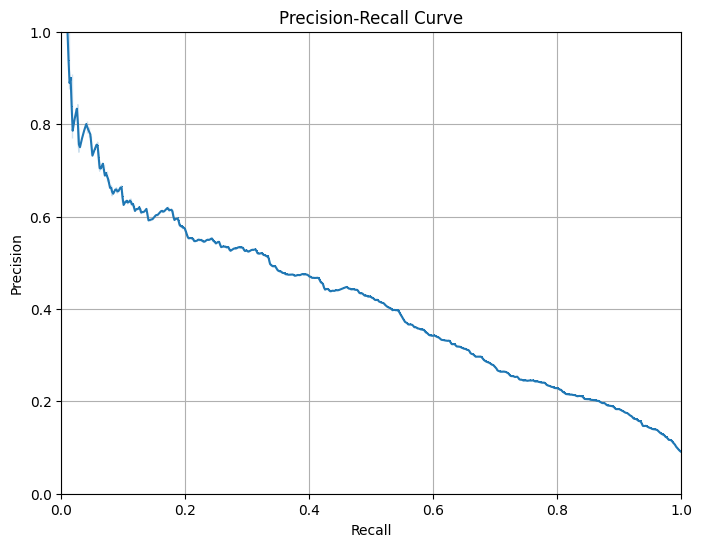

[STraTSExperiment] Test Metrics:
  AUROC: 0.8498
  AUPRC: 0.4152
  Precision: 0.5317
  Recall: 0.2948
  F1: 0.3793
  Accuracy: 0.9135
  Brier: 0.0660
  Precision@Recall_0.8: 0.2288


[Evaluating on dataset]:   0%|          | 0/310 [00:00<?, ?it/s]

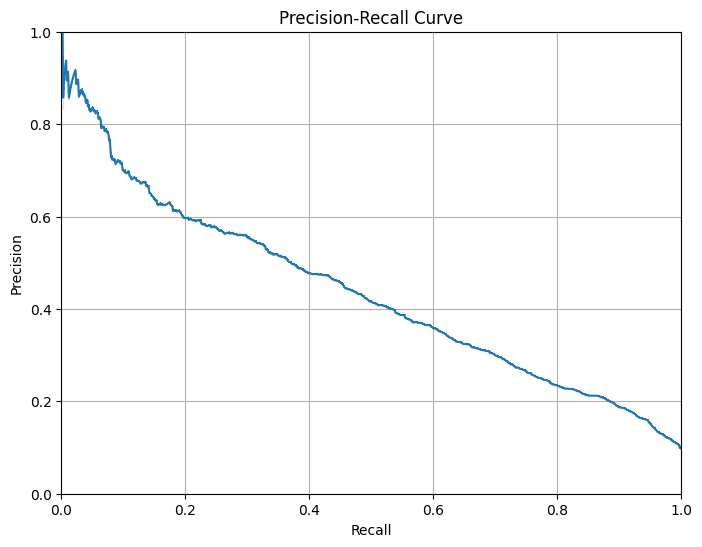

[Evaluating on dataset]:   0%|          | 0/106 [00:00<?, ?it/s]

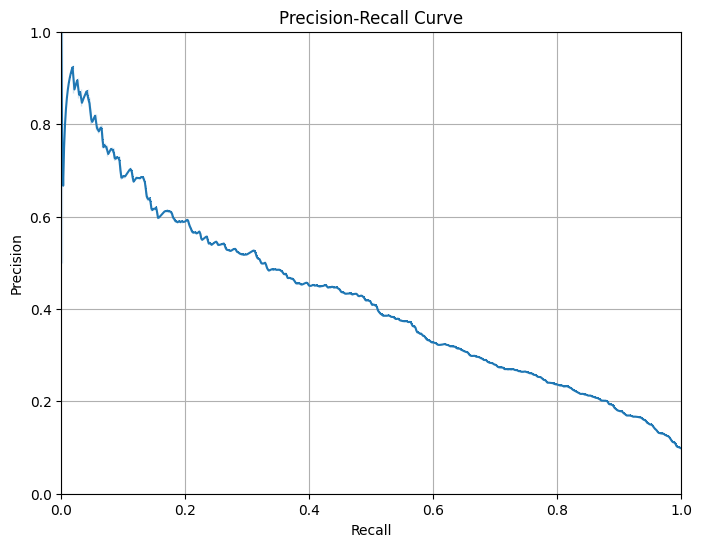

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_mor_inference_init.csv


In [11]:
# CLS final_emb
exp_0 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_loader,
    valid_loader=valid_loader,
    test_loader=test_loader,
    version='mimic_mor_inference_init',
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)

exp_0.load_downstream_model('./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt')

# 1) Pretrain
metrics_0 = exp_0.evaluate()

### Task 1

[STraTSExperiment] Initialized with version=mimic_vital_mor_inference_init, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt


[Evaluating on dataset]:   0%|          | 0/103 [00:00<?, ?it/s]

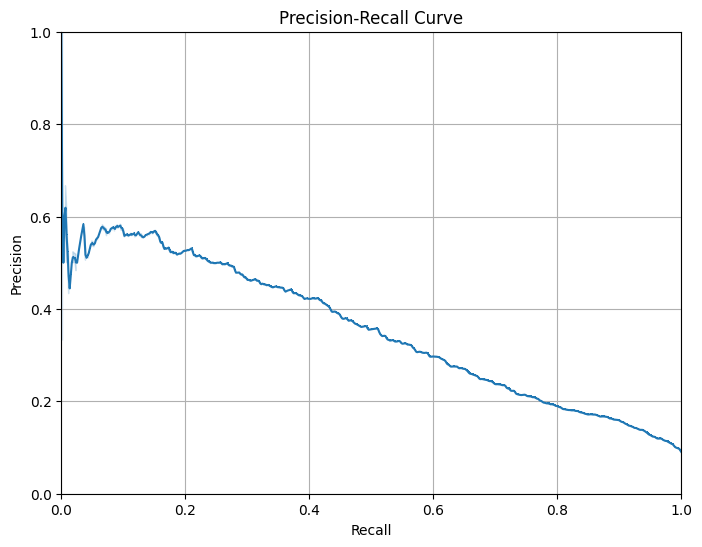

[STraTSExperiment] Test Metrics:
  AUROC: 0.8212
  AUPRC: 0.3555
  Precision: 0.5584
  Recall: 0.0730
  F1: 0.1291
  Accuracy: 0.9113
  Brier: 0.0730
  Precision@Recall_0.8: 0.1901


[Evaluating on dataset]:   0%|          | 0/306 [00:00<?, ?it/s]

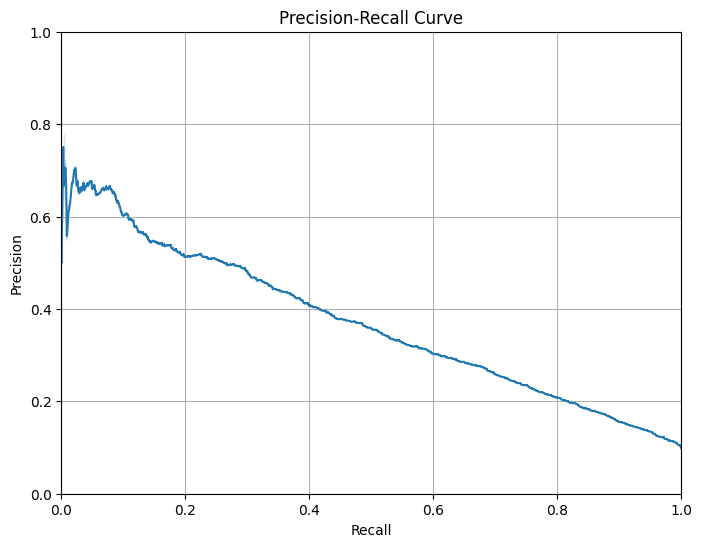

[Evaluating on dataset]:   0%|          | 0/105 [00:00<?, ?it/s]

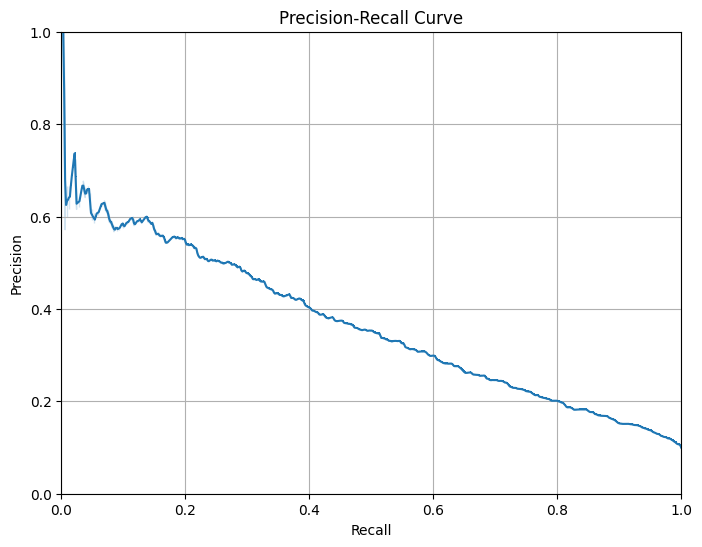

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_vital_mor_inference_init.csv


In [12]:
# Fusion final_emb
exp_1 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_vital_loader,
    valid_loader=valid_vital_loader,
    test_loader=test_vital_loader,
    version='mimic_vital_mor_inference_init',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)
exp_1.load_downstream_model('./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt')

# Evaluate
metrics_1 = exp_1.evaluate()


### Task 2

[STraTSExperiment] Initialized with version=mimic_lab_mor_inference_init, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt


[Evaluating on dataset]:   0%|          | 0/100 [00:00<?, ?it/s]

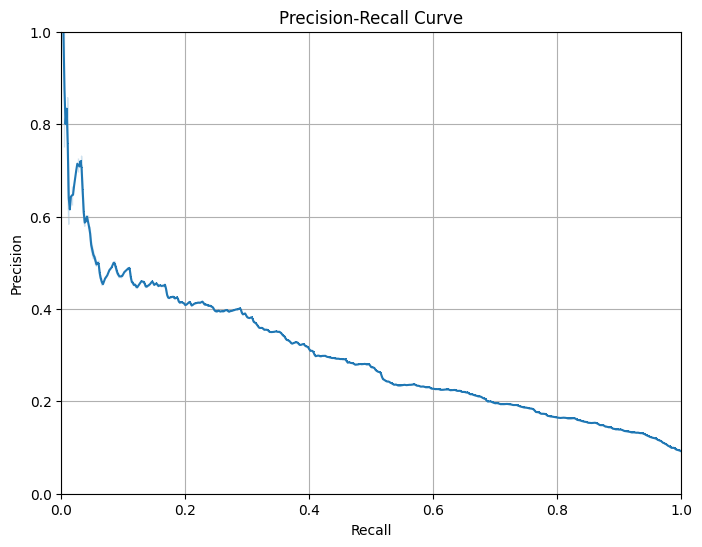

[STraTSExperiment] Test Metrics:
  AUROC: 0.7829
  AUPRC: 0.2999
  Precision: 0.7200
  Recall: 0.0310
  F1: 0.0595
  Accuracy: 0.9107
  Brier: 0.0801
  Precision@Recall_0.8: 0.1651


[Evaluating on dataset]:   0%|          | 0/296 [00:00<?, ?it/s]

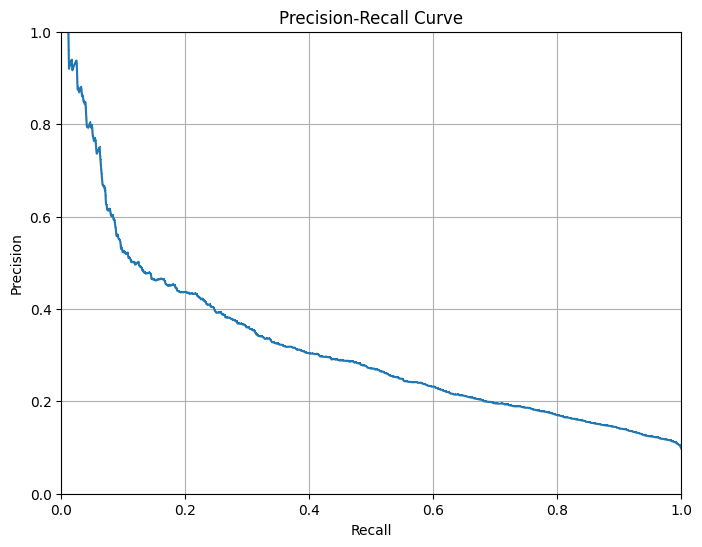

[Evaluating on dataset]:   0%|          | 0/101 [00:00<?, ?it/s]

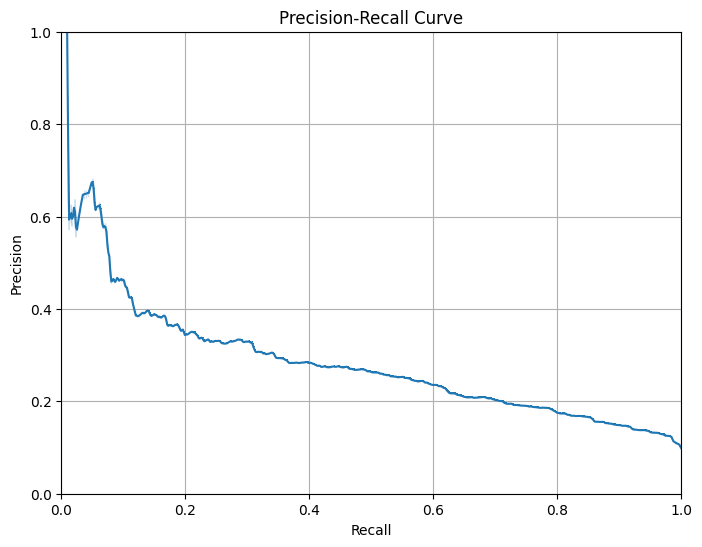

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_lab_mor_inference_init.csv


{'AUROC': 0.7829101638094784,
 'AUPRC': 0.2998623527480856,
 'Precision': 0.72,
 'Recall': 0.03103448275862069,
 'F1': 0.05950413223140496,
 'Accuracy': 0.9106890598022288,
 'Brier': 0.08009790815094221,
 'Precision@Recall_0.8': 0.16506581287797936}

In [13]:
# Lab
exp_2 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_lab_loader,
    valid_loader=valid_lab_loader,
    test_loader=test_lab_loader,
    version='mimic_lab_mor_inference_init',
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)
exp_2.load_downstream_model('./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt')

# 1) Pretrain
exp_2.evaluate()

### Task 3

[STraTSExperiment] Initialized with version=mimic_treatment_mor_inference_init, device=cuda.
[STraTSExperiment] Loaded downstream model from ./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt


[Evaluating on dataset]:   0%|          | 0/96 [00:00<?, ?it/s]

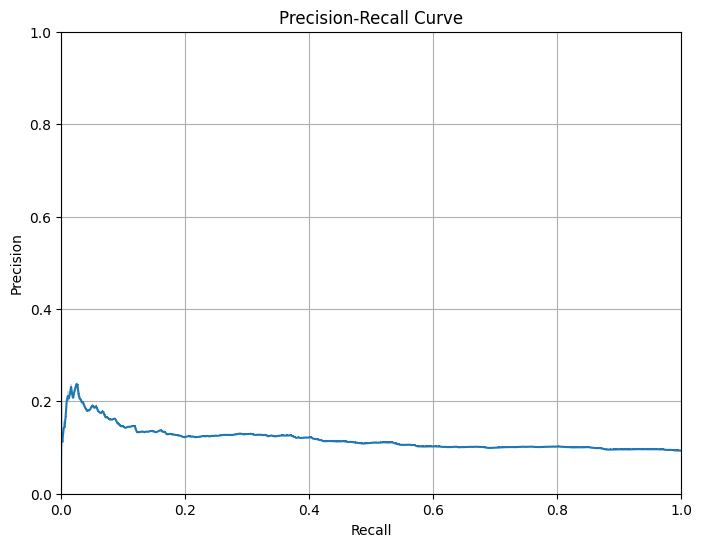

[STraTSExperiment] Test Metrics:
  AUROC: 0.5606
  AUPRC: 0.1190
  Precision: 0.1812
  Recall: 0.0436
  F1: 0.0703
  Accuracy: 0.8924
  Brier: 0.0971
  Precision@Recall_0.8: 0.1025


[Evaluating on dataset]:   0%|          | 0/288 [00:00<?, ?it/s]

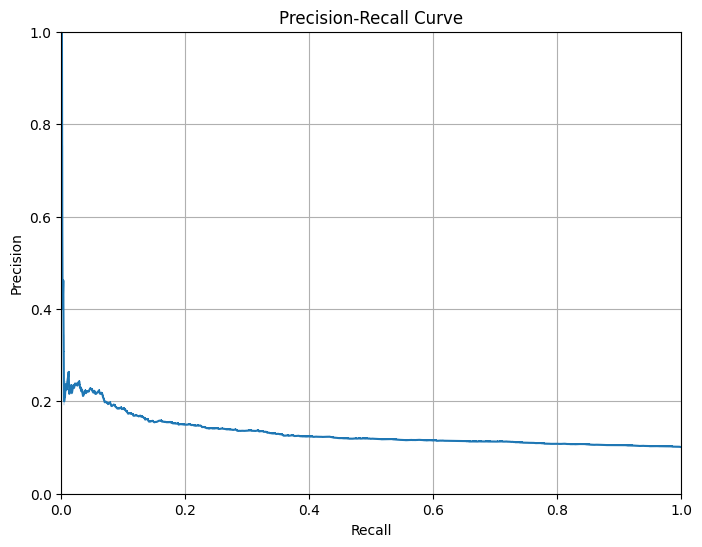

[Evaluating on dataset]:   0%|          | 0/99 [00:00<?, ?it/s]

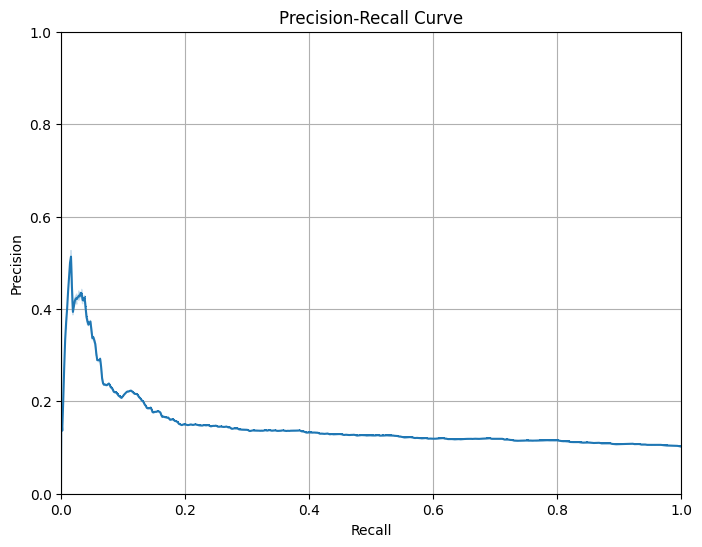

[STraTSExperiment] Saved embeddings to ./model_results\valid_embedding_mimic_treatment_mor_inference_init.csv


{'AUROC': 0.5606242617362397,
 'AUPRC': 0.11904539653980087,
 'Precision': 0.18115942028985507,
 'Recall': 0.04363001745200698,
 'F1': 0.07032348804500703,
 'Accuracy': 0.8923978512127625,
 'Brier': 0.09710320363164386,
 'Precision@Recall_0.8': 0.10249554367201426}

In [14]:
# No pretraining, cls

exp_3 = STraTSExperiment(
    emb_idx=emb_idx,            # num_features
    train_loader=train_treatment_loader,
    valid_loader=valid_treatment_loader,
    test_loader=test_treatment_loader,
    version='mimic_treatment_mor_inference_init',           # None이면 자동으로 날짜_0 형태
    num_heads=4,
    num_layers=2,
    ff_dim=64,
    embed_dim=32,
    dropout=0.2,
    time_activation='relu',
    value_activation='tanh',
    final_emb_type='fusion',
    fusion_emb_weight=0.5,
    final_emb_weight=0.5,
    patience=30,
    loss_type='bce'
)
exp_3.load_downstream_model('./models_pt/downstream_model_eicu_48h_unit_mortality_init.pt')


# Evaluate
exp_3.evaluate()